In [1]:
# PACKAGES

import random, time, pickle
from datetime import datetime
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
from model import *
from analytics import period, onset

In [2]:
# FIGURE SETTINGS

alphabet = ['(' + _ +')' for _ in 'abcdefghijklmnopqrstuvwxyz']
blues = [plt.cm.PuBu(1-val) for val in [0.0, 0.25, 0.50, 0.75]]

plt.rcParams["font.family"] = "Arial"
plt.rcParams['mathtext.fontset'] = "custom"
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
# SET CONFIGURATIONS

# Set social graph
n = 4
complete_graph=True

# Set simulation time and resolution
tmax = 5000
time_step=0.01

# Set model parameters
threshold_x = 0.5

# Set seeds
seed = 0
# seed 0: two slow adopters, but eventually all
# seed 1: one action taker only
# seed 2: no actions taken 

In [4]:
# PROCESS CONFIGURATIONS

# Create adjacency matrix
if complete_graph:
    A = np.ones((n,n))-np.eye(n) 
else:
    A = np.random.choice([1, 0], size=(n, n)) 
    A = A - np.diag(np.diag(A))

In [5]:
# LOAD OR GENERATE AND SAVE DATA

load = True
file_loc = 'data/data-for-figure-5.p'

if load:
    t, x, y, a = pickle.load(open(file_loc, 'rb'))

else:
    # INITIALIZE DATA LISTS
    t, x, y, a = list(range(3)), list(range(3)), list(range(3)), list(range(3))

    # GENERATE DATA
    for i, bias in enumerate([0.0, 0.023, 0.05]):
        np.random.seed(seed) 

        # Generate random internal attitudes
        alphas = np.sort(np.random.uniform(low=-0.4, high=1, size=n))[::-1]

        # Generate random initial condition for x
        x0 = np.random.uniform(size=n)*0.5

        # make system
        system = make_system(A, alphas, shiftS=-0.5, shiftC=0.5, scaleC=0.05,
            growth='symlogistic', threshold_x=threshold_x, 
            immediacy_parameter=bias)

        # INTEGRATE
        t[i], x[i], y[i] = integrate_system(system, t_max=tmax, 
            time_step=time_step, max_events=1E4) #TODO: add initial condition or not?
        a[i] = np.copy(alphas)
        
    # SAVE DATA
    pickle.dump([t, x, y, a], open(file_loc, 'wb'))

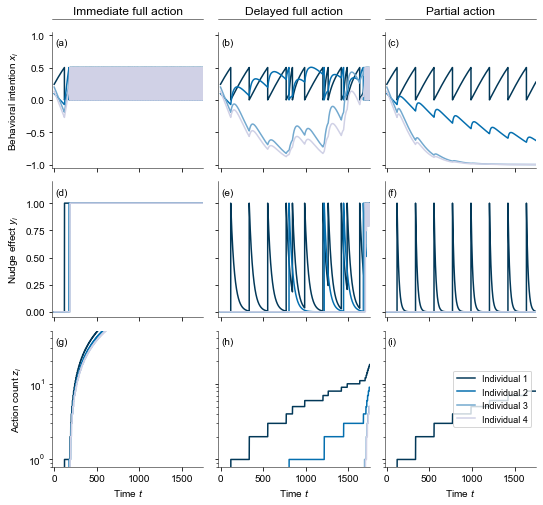

In [7]:
# PLOT FIGURE

# plot titles and ranges
plot_titles = ["Immediate full action\n", 
               "Delayed full action\n", 
               "Partial action\n"]
ylabels = [r'Behavioral intention $x_i$',
           r'Nudge effect $y_i$',
           r'Action count $z_i$']
xlims = [-25,1750]
xticks = [0,500,1000,1500]

# initialize figure
fig = plt.figure(figsize=(8,8))

for j in range(3):

    ax1 = plt.subplot(3,3,1+j)
    
    # add column titles
    plt.title(plot_titles[j], fontsize=12)

    # underline titles
    ax1.plot([0,1], [1.095,1.095], color='black', lw=0.5, 
        transform=ax1.transAxes, clip_on=False)        
            
    # plot simulation results
    ax1.text(0.02, 0.9, alphabet[j], transform=ax1.transAxes)
    for i in range(n):
        plt.plot(t[j], x[j][i], color=blues[i], ls='-', 
            label='Individual '+str(i+1))
    plt.ylim([-1.05,1.05])
    plt.xlim(xlims)

    plt.xlabel('')
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([])
    if j==0:
        plt.ylabel(r'Behavioral intention $x_i$')
    else:
        ax1.set_yticklabels([])

    ax2 = plt.subplot(3,3,4+j) 
    ax2.text(0.02, 0.9, alphabet[3+j], transform=ax2.transAxes)
    for i in range(n):
        plt.plot(t[j], x[j][n+i], color=blues[i], ls='-', 
            label='Individual '+str(i+1))
    plt.ylim([-0.05,1.2])
    plt.xlim(xlims)

    plt.xlabel('')
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([])
    if j==0:
        plt.ylabel(r'Nudge effect $y_i$')
    else:
        ax2.set_yticklabels([])

    ax3 = plt.subplot(3,3,7+j)
    ax3.text(0.02, 0.9, alphabet[6+j], transform=ax3.transAxes)
    for i in range(n):
        plt.semilogy(t[j], y[j][i], color=blues[i], ls='-', 
            label='Individual '+str(i+1))
    plt.ylim([0.8,50])
    plt.xlim(xlims)

    plt.xlabel(r'Time $t$')
    ax3.set_xticks(xticks)
    if j==0:
        plt.ylabel(r'Action count $z_i$')
    else:
        ax3.set_yticklabels([])
    if j==2:
        plt.legend(loc=7, fontsize=9)
        
plt.subplots_adjust(hspace=0.1, wspace=0.1, left=0.08, right=0.92)

# Get the current date-time string
current_datetime = datetime.now()
dts = current_datetime.strftime("%Y-%m-%d_%H.%M.%S")

# save figure with current date and time
plt.savefig('figures/figure-5_'+dts+'.pdf', bbox_inches="tight")